# Problema 4 - Mediciones de tiempo
Medimos el tiempo de ejecucion del algoritmo de programacion dinamica para descomposicion minima en palindromos y lo contrastamos con una referencia cuadratica $O(n^2)$.

In [1]:
%pip install -q matplotlib seaborn scipy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import random
import numpy as np
import scipy as sp
import seaborn as sns
from matplotlib import pyplot as plt

# Importamos modulos desde el directorio actual y su padre
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(current_dir)
sys.path.append(parent_dir)

# Importamos la función a probar
from problema_4 import min_palindromos
from util import time_algorithm

# Establecemos semillas para la reproducibilidad de los resultados
random.seed(12345)
np.random.seed(12345)
sns.set_theme(style="whitegrid")

## Generacion de datos para las mediciones y graficos
Para cada tamano $n$, generamos una cadena aleatoria reproducible sobre un alfabeto fijo y medimos el tiempo promedio de `min_palindromos`.

Luego convertimos los tiempos a milisegundos y ajustamos los valores medidos contra una referencia teorica cuadratica $O(n^2)$.

In [20]:
ALFABETO = "ABCDE"

def generar_cadena(n: int) -> str:
    return "".join(random.choice(ALFABETO) for _ in range(int(n)))

def args_tiempo(n: int):
    return (generar_cadena(int(n)),)

x = np.linspace(50, 600, 20).astype(int)
print("rango:", x)

results_tiempo_s = time_algorithm(min_palindromos, x, args_tiempo)
results_tiempo = {int(n): t * 1000.0 for n, t in results_tiempo_s.items()}

print("Resultados (ms):")
for n, t in results_tiempo.items():
    print(f"Tiempo para n={n}: {t:.12g} ms")

rango: [ 50  78 107 136 165 194 223 252 281 310 339 368 397 426 455 484 513 542
 571 600]
Resultados (ms):
Tiempo para n=50: 0.155591964722 ms
Tiempo para n=78: 0.390148162842 ms
Tiempo para n=107: 0.734972953796 ms
Tiempo para n=136: 1.25608444214 ms
Tiempo para n=165: 1.55818462372 ms
Tiempo para n=194: 2.34196186066 ms
Tiempo para n=223: 2.89769172668 ms
Tiempo para n=252: 3.70583534241 ms
Tiempo para n=281: 5.0172328949 ms
Tiempo para n=310: 6.65452480316 ms
Tiempo para n=339: 7.88836479187 ms
Tiempo para n=368: 10.0610256195 ms
Tiempo para n=397: 12.2838020325 ms
Tiempo para n=426: 14.518904686 ms
Tiempo para n=455: 17.0746803284 ms
Tiempo para n=484: 19.7255373001 ms
Tiempo para n=513: 21.5822696686 ms
Tiempo para n=542: 23.1292247772 ms
Tiempo para n=571: 25.9033679962 ms
Tiempo para n=600: 30.4234743118 ms


c_1 = 8.39715639867e-05, c_2 = -0.825616155251
Error cuadratico total: 7.79834847095


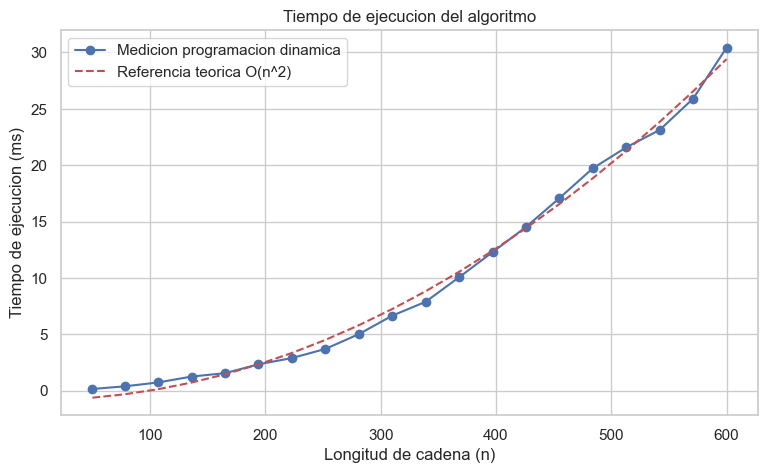

In [21]:
# scipy nos pide una función que recibe primero x y luego los parámetros a ajustar:
f_tiempo = lambda x, c1, c2: c1 * x**2 + c2
c, _ = sp.optimize.curve_fit(f_tiempo, x, [results_tiempo[n] for n in x])
r = np.sum((c[0] * x**2 + c[1] - [results_tiempo[n] for n in x])**2)

print(f"c_1 = {c[0]:.12g}, c_2 = {c[1]:.12g}")
print(f"Error cuadratico total: {r:.12g}")

ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, [results_tiempo[n] for n in x], "o-", label="Medicion programacion dinamica")
ax.plot(x, [c[0] * n**2 + c[1] for n in x], "r--", label="Referencia teorica O(n^2)")
ax.set_title("Tiempo de ejecucion del algoritmo")
ax.set_xlabel("Longitud de cadena (n)")
ax.set_ylabel("Tiempo de ejecucion (ms)")
ax.legend()

Text(0, 0.5, 'Error absoluto (ms)')

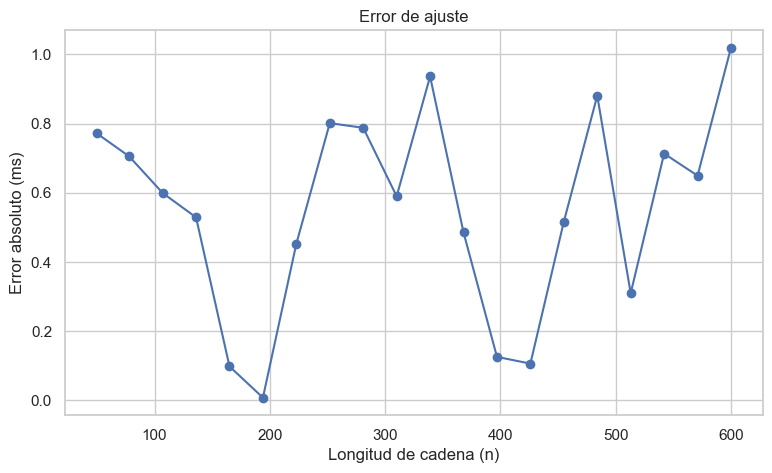

In [22]:
ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
errors = [np.abs(c[0] * n**2 + c[1] - results_tiempo[n]) for n in x]
ax.plot(x, errors, "o-")
ax.set_title("Error de ajuste")
ax.set_xlabel("Longitud de cadena (n)")
ax.set_ylabel("Error absoluto (ms)")